# Capstone Project 1

## Predictive Maintenance

### Import Libraries and Load Dataset

In [7]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
df = pd.read_csv("../data/predictive_maintenance.csv")

In [9]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [10]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 9)


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 703.3 KB


In [12]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [13]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['Target'].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

### Exploratory Data Analysis (EDA)

In [16]:
# ==========================================
# Set Plot Style
# ==========================================

import os

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Create images folder if it doesn't exist
os.makedirs("../images", exist_ok=True)

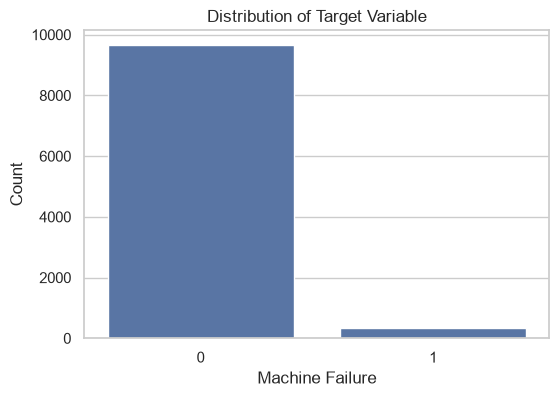

In [18]:
# Target Variable Distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Target')

plt.title("Distribution of Target Variable")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.savefig("../images/target_distribution.png", dpi=300)

plt.show()

In [19]:
target_percent = df['Target'].value_counts(normalize=True) * 100

print(target_percent)

Target
0    96.61
1     3.39
Name: proportion, dtype: float64


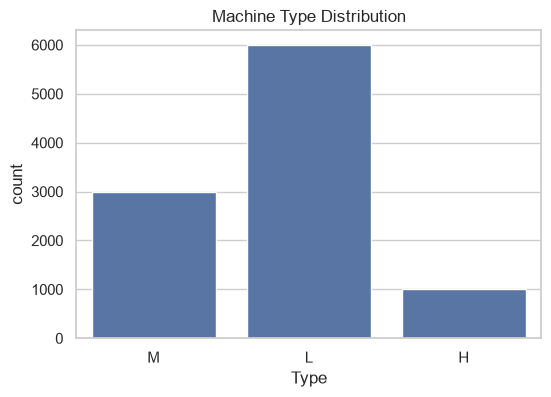

In [20]:
#  Product Type Distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Type')

plt.title("Machine Type Distribution")

plt.savefig("../images/type_distribution.png", dpi=300)

plt.show()

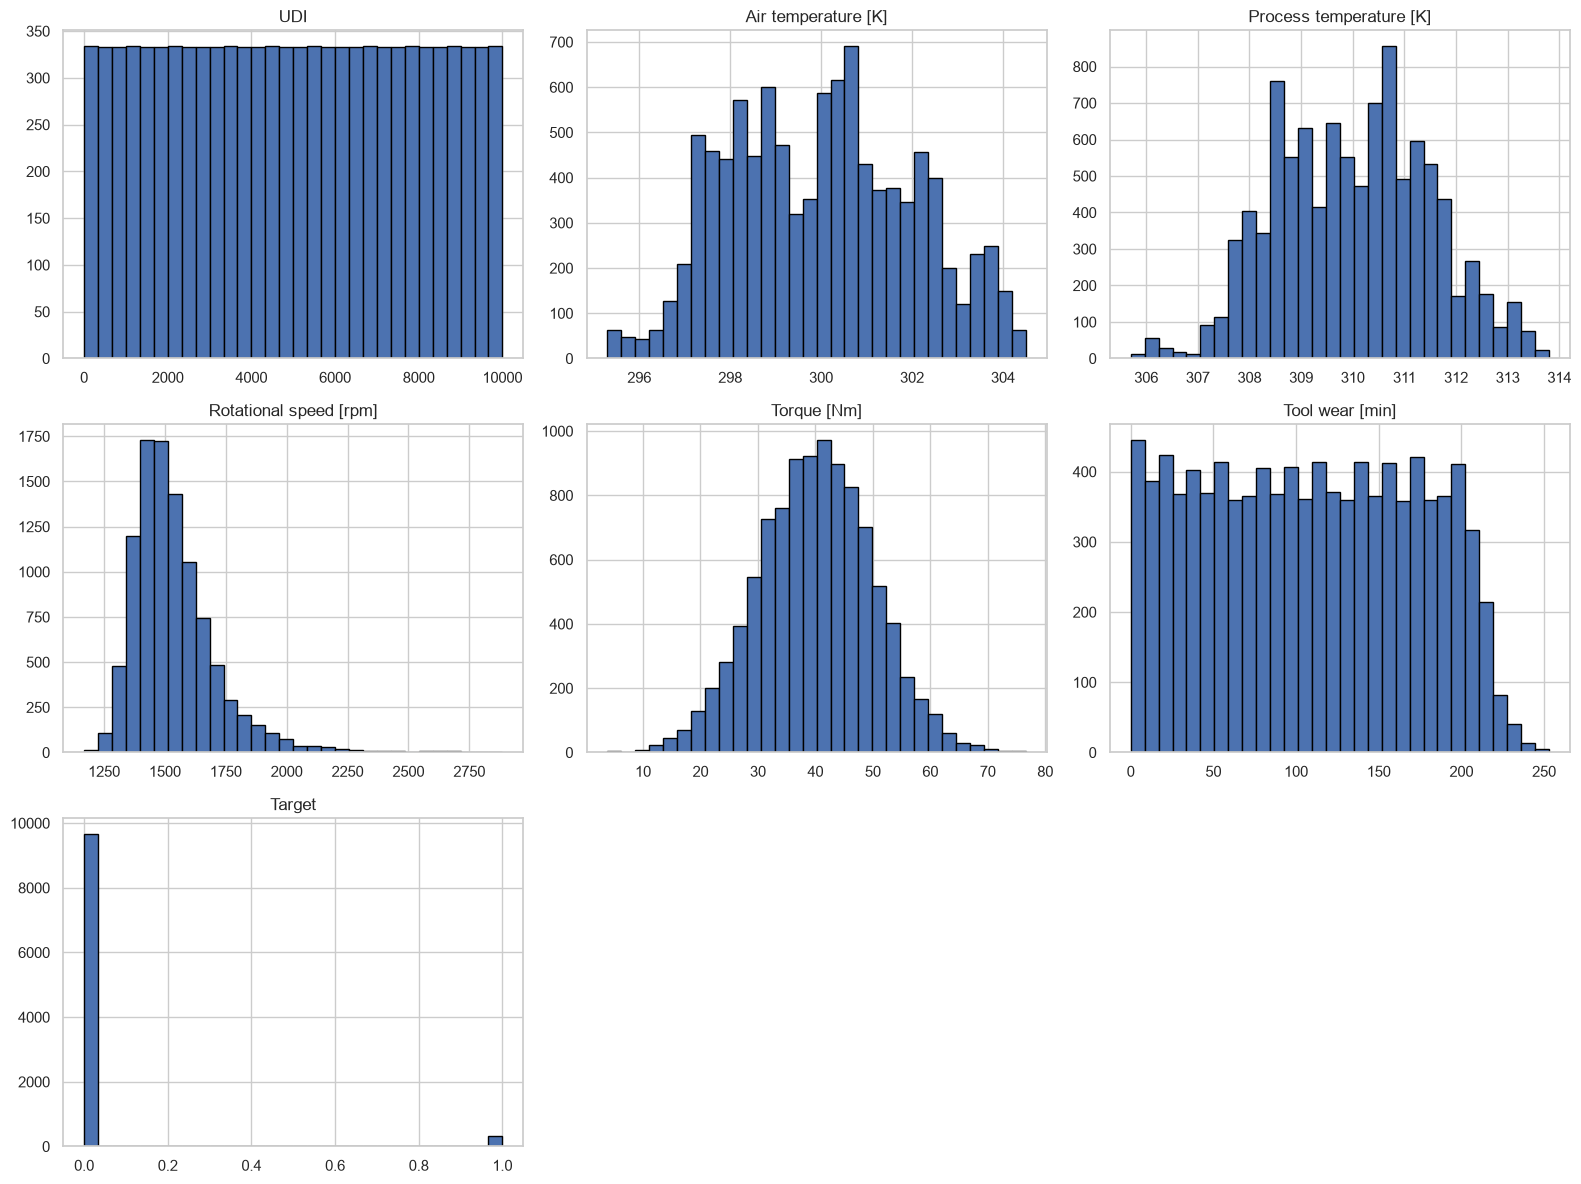

In [21]:
# Histograms of Numerical Variables
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

df[numerical_columns].hist(
    figsize=(16,12),
    bins=30,
    edgecolor='black'
)

plt.tight_layout()

plt.savefig("../images/histograms.png", dpi=300)

plt.show()

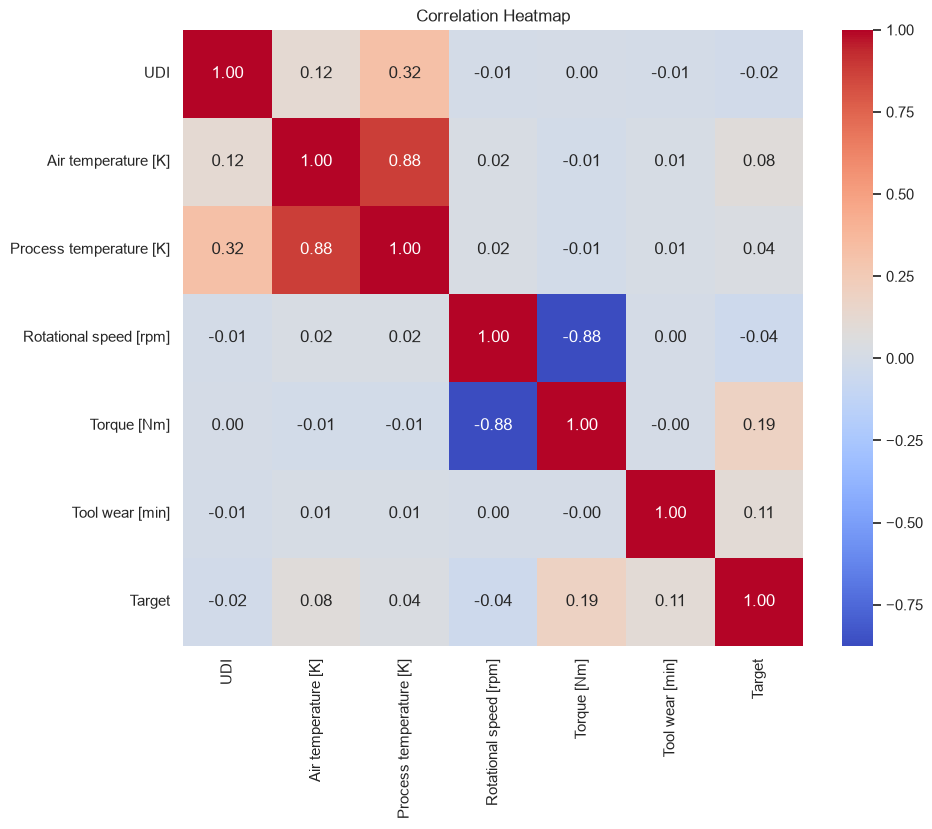

In [23]:
# Correlation Matrix
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png", dpi=300)

plt.show()

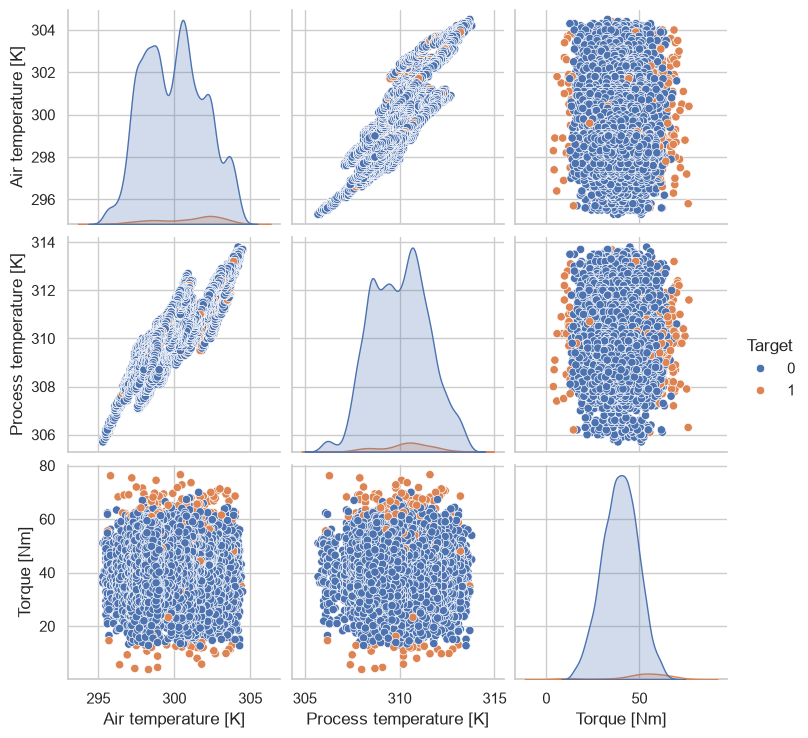

In [24]:
# Pairplot (Selected Features)
selected = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Torque [Nm]',
    'Target'
]

sns.pairplot(
    df[selected],
    hue='Target'
)

plt.savefig("../images/pairplot.png", dpi=300)

plt.show()

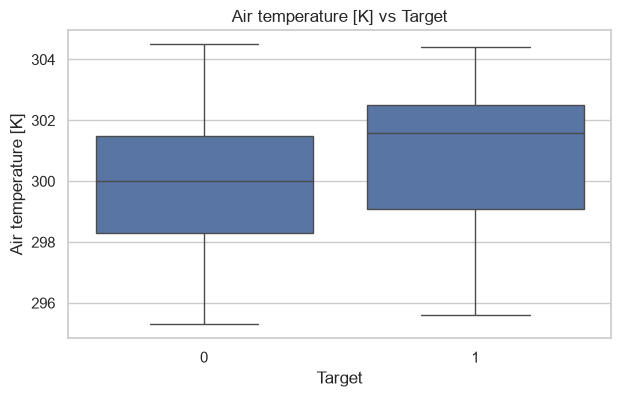

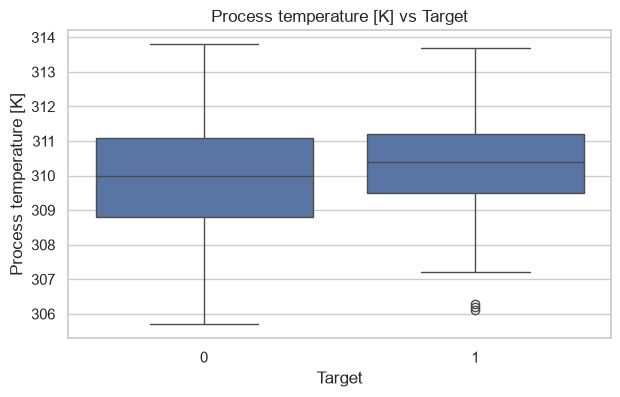

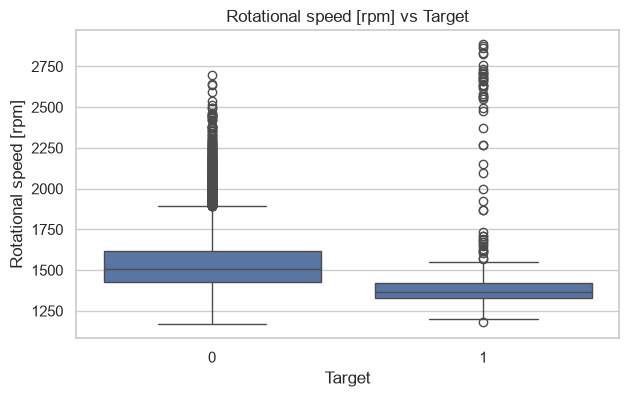

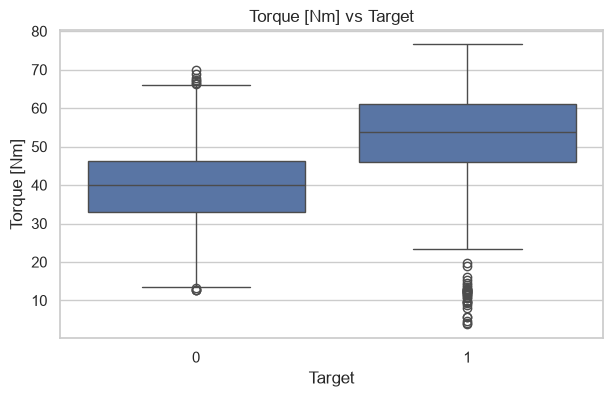

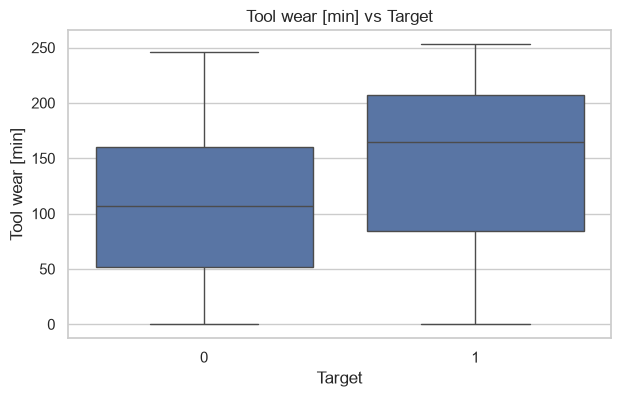

In [25]:
# Distribution of Numerical Features by Target
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for feature in features:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x='Target',
        y=feature,
        data=df
    )

    plt.title(f"{feature} vs Target")

    plt.savefig(f"../images/{feature}_vs_target.png", dpi=300)

    plt.show()

In [26]:
# Category-wise Failure Rate
failure_rate = pd.crosstab(
    df['Type'],
    df['Target'],
    normalize='index'
) * 100

failure_rate

Target,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


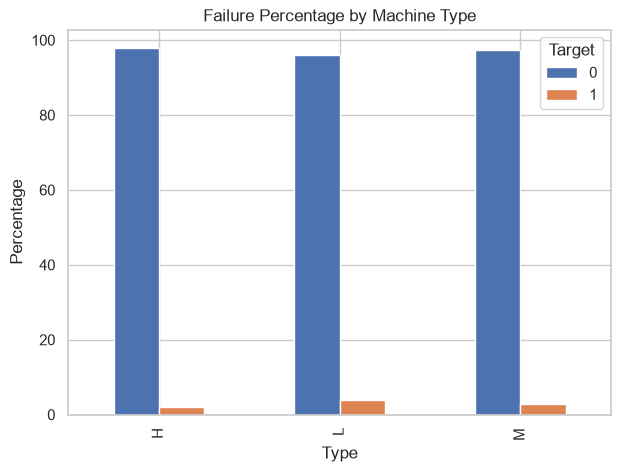

In [27]:
failure_rate.plot(kind='bar', figsize=(7,5))

plt.ylabel("Percentage")

plt.title("Failure Percentage by Machine Type")

plt.savefig("../images/failure_rate_by_type.png", dpi=300)

plt.show()

In [28]:
# Summary Statistics by Target
df.groupby('Target').mean(numeric_only=True)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Target,,,,,,
0,5012.878791,299.973999,309.995570,1540.260014,39.629655,106.693717
1,4647.722714,300.886431,310.290265,1496.486726,50.168142,143.781711


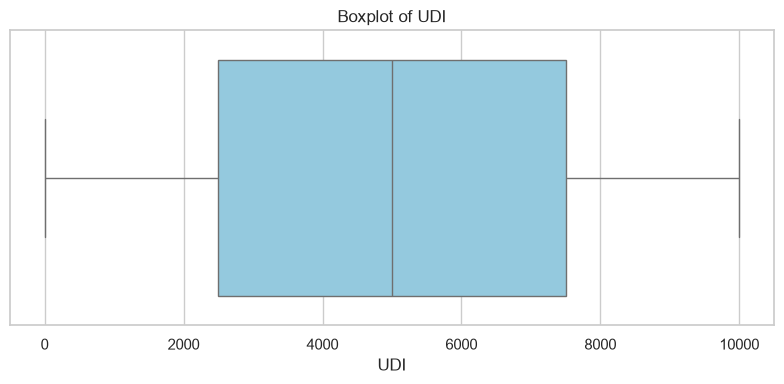

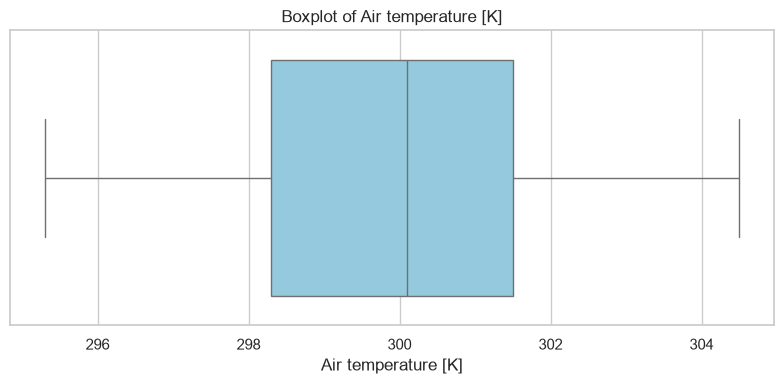

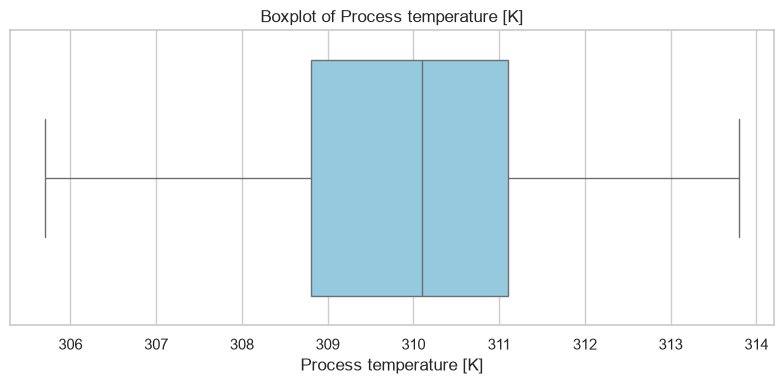

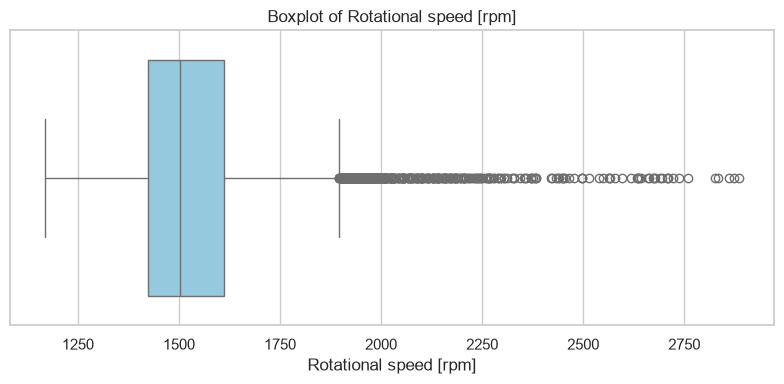

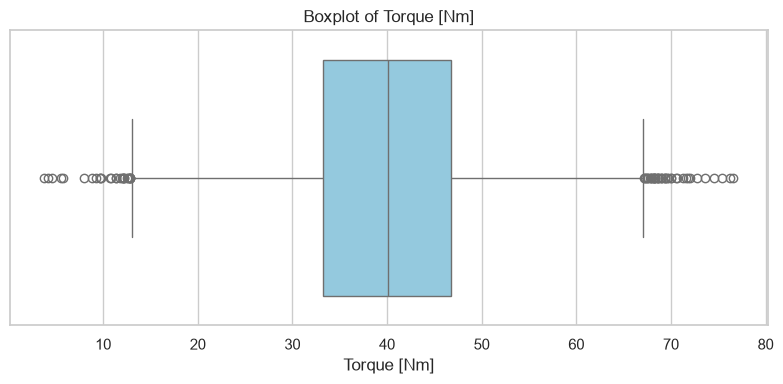

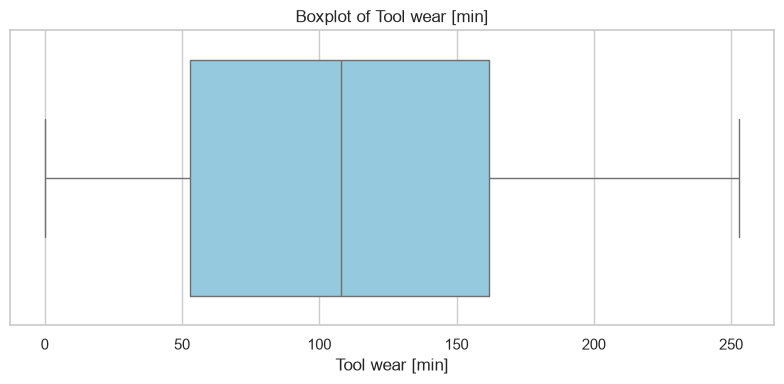

In [29]:

# Boxplots for Outlier Detection

import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Remove Target from boxplots
numerical_columns = numerical_columns.drop('Target')

for column in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[column], color='skyblue')

    plt.title(f'Boxplot of {column}')

    plt.xlabel(column)

    plt.tight_layout()

    plt.savefig(f'../images/{column}_boxplot.png', dpi=300)

    plt.show()

In [30]:
# Detect Outliers using IQR


outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    outlier_summary.append({
        'Feature': column,
        'Outliers': len(outliers),
        'Percentage': round((len(outliers)/len(df))*100,2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Feature,Outliers,Percentage
0,UDI,0,0.00
1,Air temperature [K],0,0.00
2,Process temperature [K],0,0.00
3,Rotational speed [rpm],418,4.18
4,Torque [Nm],69,0.69
5,Tool wear [min],0,0.00


Outliers were identified using the Interquartile Range (IQR) method. Among the numerical variables, rotational speed contained 418 outliers (4.18%), while torque contained 69 outliers (0.69%). Air temperature, process temperature, and tool wear did not contain any significant outliers. Since the identified outliers represent genuine machine operating conditions rather than data entry errors, they were retained for model development. Retaining these observations helps preserve important information related to abnormal machine behavior and potential failures, particularly for tree-based classification algorithms.

### Data Preprocessing

In [31]:
# Create a Copy of Dataset

df_ml = df.copy()

df_ml.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [32]:
# Drop Identifier Columns

df_ml.drop(['UDI', 'Product ID'], axis=1, inplace=True)

df_ml.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [33]:
print(df_ml.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target'],
      dtype='str')


In [34]:
# Encode the Categorical Feature

df_ml['Type'].unique()

<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str

In [35]:
# Apply Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_ml['Type'] = le.fit_transform(df_ml['Type'])

df_ml.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


In [36]:
# Verify Encoding
mapping = pd.DataFrame({
    'Original': le.classes_,
    'Encoded': range(len(le.classes_))
})

mapping

,Original,Encoded
0,H,0
1,L,1
2,M,2


In [37]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  int64  
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Target                   10000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 547.0 KB


In [77]:
import joblib

joblib.dump(le, "../models/label_encoder.pkl")

['../models/label_encoder.pkl']

In [38]:
# Separate Features and Target

X = df_ml.drop('Target', axis=1)

y = df_ml['Target']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (10000, 6)
Target Shape : (10000,)


In [39]:
# Check Class Distribution
print(y.value_counts())

print("\nPercentage")

print(round(y.value_counts(normalize=True)*100,2))

Target
0    9661
1     339
Name: count, dtype: int64

Percentage
Target
0    96.61
1     3.39
Name: proportion, dtype: float64


In [40]:
# Split the Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [41]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (8000, 6)
Testing Features : (2000, 6)
Training Target : (8000,)
Testing Target : (2000,)


In [42]:
# Scale the Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [43]:
# Convert Back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

In [44]:
X_train_scaled.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,1.341257,0.998914,0.604282,-0.460607,0.718305,-0.843997
1,1.341257,-1.505194,-1.153260,-0.775574,0.638456,0.382263
2,1.341257,0.498092,1.077466,-1.007654,0.558607,0.460870
3,-0.333221,-0.553633,-0.139294,-0.709265,1.626586,-0.372359
4,-0.333221,-1.455112,-1.018064,1.070019,-1.128202,-0.906882


In [45]:
# Apply SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [46]:
# Check Class Balance
print("Before SMOTE")

print(y_train.value_counts())

print("\nAfter SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
Target
0    7729
1     271
Name: count, dtype: int64

After SMOTE
Target
0    7729
1    7729
Name: count, dtype: int64


In [47]:
print("Training Shape Before SMOTE")

print(X_train_scaled.shape)

print("\nTraining Shape After SMOTE")

print(X_train_smote.shape)

Training Shape Before SMOTE
(8000, 6)

Training Shape After SMOTE
(15458, 6)


In [48]:
# Save the Scaler
import joblib

joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

### Build and Compare Machine Learning Models

In [49]:
# Import Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [50]:
# Function to Evaluate Models

def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    # Metrics
    train_acc = model.score(X_train, y_train)
    test_acc = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc = roc_auc_score(y_test, y_prob)

    print("="*60)
    print(model.__class__.__name__)
    print("="*60)

    print("Training Accuracy :", round(train_acc,4))
    print("Testing Accuracy :", round(test_acc,4))
    print("Precision :", round(precision,4))
    print("Recall :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC :", round(roc,4))

    print("\nClassification Report\n")

    print(classification_report(y_test,y_pred))

    return [
        model.__class__.__name__,
        train_acc,
        test_acc,
        precision,
        recall,
        f1,
        roc
    ]

In [51]:
# Logistic Regression
log_model = LogisticRegression(random_state=42)

log_results = evaluate_model(
    log_model,
    X_train_smote,
    X_test_scaled,
    y_train_smote,
    y_test
)

LogisticRegression
Training Accuracy : 0.8205
Testing Accuracy : 0.823
Precision : 0.1425
Recall : 0.8382
F1 Score : 0.2436
ROC AUC : 0.9074

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.84      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.82      0.88      2000



In [52]:
# Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_results = evaluate_model(
    dt_model,
    X_train_smote,
    X_test_scaled,
    y_train_smote,
    y_test
)

DecisionTreeClassifier
Training Accuracy : 1.0
Testing Accuracy : 0.956
Precision : 0.4123
Recall : 0.6912
F1 Score : 0.5165
ROC AUC : 0.8282

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.41      0.69      0.52        68

    accuracy                           0.96      2000
   macro avg       0.70      0.83      0.75      2000
weighted avg       0.97      0.96      0.96      2000



In [53]:
# Random Forest
rf_model = RandomForestClassifier(
    random_state=42
)

rf_results = evaluate_model(
    rf_model,
    X_train_smote,
    X_test_scaled,
    y_train_smote,
    y_test
)

RandomForestClassifier
Training Accuracy : 1.0
Testing Accuracy : 0.9705
Precision : 0.5464
Recall : 0.7794
F1 Score : 0.6424
ROC AUC : 0.9702

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.55      0.78      0.64        68

    accuracy                           0.97      2000
   macro avg       0.77      0.88      0.81      2000
weighted avg       0.98      0.97      0.97      2000



In [54]:
# K-Nearest Neighbors
knn_model = KNeighborsClassifier()

knn_results = evaluate_model(
    knn_model,
    X_train_smote,
    X_test_scaled,
    y_train_smote,
    y_test
)

KNeighborsClassifier
Training Accuracy : 0.9764
Testing Accuracy : 0.932
Precision : 0.3023
Recall : 0.7647
F1 Score : 0.4333
ROC AUC : 0.8966

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1932
           1       0.30      0.76      0.43        68

    accuracy                           0.93      2000
   macro avg       0.65      0.85      0.70      2000
weighted avg       0.97      0.93      0.95      2000



In [55]:
# Support Vector Machine
svm_model = SVC(
    probability=True,
    random_state=42
)

svm_results = evaluate_model(
    svm_model,
    X_train_smote,
    X_test_scaled,
    y_train_smote,
    y_test
)

SVC
Training Accuracy : 0.9491
Testing Accuracy : 0.92
Precision : 0.285
Recall : 0.8971
F1 Score : 0.4326
ROC AUC : 0.9642

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.92      0.96      1932
           1       0.29      0.90      0.43        68

    accuracy                           0.92      2000
   macro avg       0.64      0.91      0.69      2000
weighted avg       0.97      0.92      0.94      2000



In [56]:
# Comparison Table
comparison = pd.DataFrame(

    [
        log_results,
        dt_results,
        rf_results,
        knn_results,
        svm_results
    ],

    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]

)

comparison

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.820546,0.8230,0.142500,0.838235,0.243590,0.907358
1,DecisionTreeClassifier,1.000000,0.9560,0.412281,0.691176,0.516484,0.828249
2,RandomForestClassifier,1.000000,0.9705,0.546392,0.779412,0.642424,0.970211
3,KNeighborsClassifier,0.976388,0.9320,0.302326,0.764706,0.433333,0.896602
4,SVC,0.949088,0.9200,0.285047,0.897059,0.432624,0.964172


In [57]:
comparison.iloc[:,1:] = comparison.iloc[:,1:].round(4)

comparison

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.8205,0.8230,0.1425,0.8382,0.2436,0.9074
1,DecisionTreeClassifier,1.0000,0.9560,0.4123,0.6912,0.5165,0.8282
2,RandomForestClassifier,1.0000,0.9705,0.5464,0.7794,0.6424,0.9702
3,KNeighborsClassifier,0.9764,0.9320,0.3023,0.7647,0.4333,0.8966
4,SVC,0.9491,0.9200,0.2850,0.8971,0.4326,0.9642


In [58]:
comparison.to_csv("../reports/model_comparison.csv", index=False)

In [59]:
# Identify the Best Model
best_model = comparison.sort_values(
    by="Test Accuracy",
    ascending=False
)

best_model

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC
2,RandomForestClassifier,1.0000,0.9705,0.5464,0.7794,0.6424,0.9702
1,DecisionTreeClassifier,1.0000,0.9560,0.4123,0.6912,0.5165,0.8282
3,KNeighborsClassifier,0.9764,0.9320,0.3023,0.7647,0.4333,0.8966
4,SVC,0.9491,0.9200,0.2850,0.8971,0.4326,0.9642
0,LogisticRegression,0.8205,0.8230,0.1425,0.8382,0.2436,0.9074


In [60]:
import joblib

joblib.dump(
    rf_model,
    "../models/best_model.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.


In [8]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "LogisticRegression",
        "DecisionTreeClassifier",
        "RandomForestClassifier",
        "KNeighborsClassifier",
        "SVC"
    ],
    "Train Accuracy": [
        0.8205,
        1.0000,
        1.0000,
        0.9764,
        0.9491
    ],
    "Test Accuracy": [
        0.8230,
        0.9560,
        0.9705,
        0.9320,
        0.9200
    ],
    "Precision": [
        0.1425,
        0.4123,
        0.5464,
        0.3023,
        0.2850
    ],
    "Recall": [
        0.8382,
        0.6912,
        0.7794,
        0.7647,
        0.8971
    ],
    "F1 Score": [
        0.2436,
        0.5165,
        0.6424,
        0.4333,
        0.4326
    ],
    "ROC AUC": [
        0.9074,
        0.8282,
        0.9702,
        0.8966,
        0.9642
    ]
})

comparison

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.8205,0.8230,0.1425,0.8382,0.2436,0.9074
1,DecisionTreeClassifier,1.0000,0.9560,0.4123,0.6912,0.5165,0.8282
2,RandomForestClassifier,1.0000,0.9705,0.5464,0.7794,0.6424,0.9702
3,KNeighborsClassifier,0.9764,0.9320,0.3023,0.7647,0.4333,0.8966
4,SVC,0.9491,0.9200,0.2850,0.8971,0.4326,0.9642


In [9]:
best = comparison.sort_values(
    by="Test Accuracy",
    ascending=False
).iloc[0]

print(best)

Model             RandomForestClassifier
Train Accuracy                       1.0
Test Accuracy                     0.9705
Precision                         0.5464
Recall                            0.7794
F1 Score                          0.6424
ROC AUC                           0.9702
Name: 2, dtype: object


Among all the evaluated machine learning models, the Random Forest Classifier achieved the best overall performance. It obtained a testing accuracy of 97.05% and a ROC-AUC score of 0.9702, indicating excellent discrimination between failure and non-failure cases. The model also achieved a recall of 77.94%, demonstrating its ability to identify a large proportion of machine failures. Since predictive maintenance prioritizes detecting potential failures before they occur, recall and ROC-AUC were considered alongside accuracy. Based on these metrics, the Random Forest Classifier was selected as the final deployment model.

### Hyperparameter Tuning and Final Model Evaluation

In [61]:
# Hyperparameter Tuning Libraries

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

In [62]:
# Parameter Grid

param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [None, 10, 20],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]

}

In [63]:
# Grid Search

grid_search = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1,

    verbose=2

)

grid_search.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.3s
[CV] END ma

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples

In [64]:
print("Best Parameters:")

grid_search.best_params_

Best Parameters:


{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [65]:
print("Best Cross Validation Accuracy:")

grid_search.best_score_

Best Cross Validation Accuracy:


np.float64(0.9831804182153838)

In [66]:
best_rf = grid_search.best_estimator_

best_rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [67]:
# Evaluate the Tuned Model
y_pred = best_rf.predict(X_test_scaled)

y_prob = best_rf.predict_proba(X_test_scaled)[:,1]

In [68]:
print("Training Accuracy:",
      best_rf.score(X_train_smote, y_train_smote))

print("Testing Accuracy:",
      accuracy_score(y_test,y_pred))

print("Precision:",
      precision_score(y_test,y_pred))

print("Recall:",
      recall_score(y_test,y_pred))

print("F1 Score:",
      f1_score(y_test,y_pred))

print("ROC AUC:",
      roc_auc_score(y_test,y_prob))

Training Accuracy: 1.0
Testing Accuracy: 0.9705
Precision: 0.5463917525773195
Recall: 0.7794117647058824
F1 Score: 0.6424242424242425
ROC AUC: 0.9769554560954818


In [69]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.55      0.78      0.64        68

    accuracy                           0.97      2000
   macro avg       0.77      0.88      0.81      2000
weighted avg       0.98      0.97      0.97      2000



<Figure size 600x500 with 0 Axes>

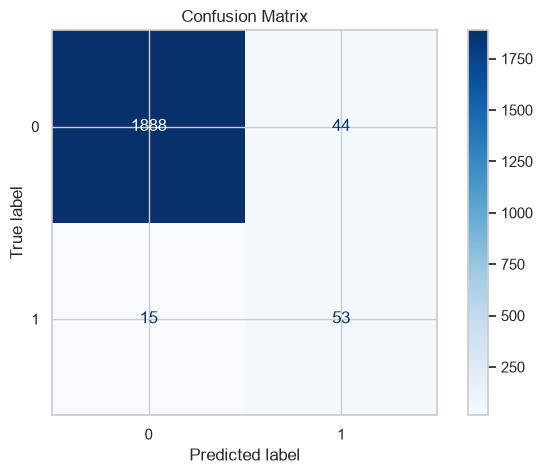

In [70]:
# Confusion Matrix
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_estimator(

    best_rf,

    X_test_scaled,

    y_test,

    cmap='Blues'

)

plt.title("Confusion Matrix")

plt.savefig("../images/confusion_matrix.png",
            dpi=300)

plt.show()

<Figure size 700x600 with 0 Axes>

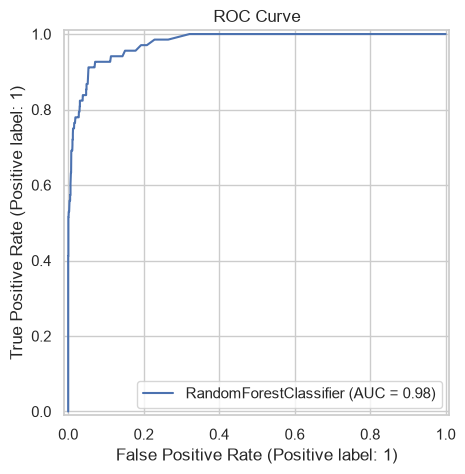

In [71]:
# ROC curve
plt.figure(figsize=(7,6))

RocCurveDisplay.from_estimator(

    best_rf,

    X_test_scaled,

    y_test

)

plt.title("ROC Curve")

plt.savefig("../images/roc_curve.png",
            dpi=300)

plt.show()

In [72]:
# Feature Importance
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': best_rf.feature_importances_

})

importance = importance.sort_values(

    by='Importance',

    ascending=False
)

importance

,Feature,Importance
4,Torque [Nm],0.323841
3,Rotational speed [rpm],0.276831
5,Tool wear [min],0.209980
1,Air temperature [K],0.096544
2,Process temperature [K],0.064609
0,Type,0.028194


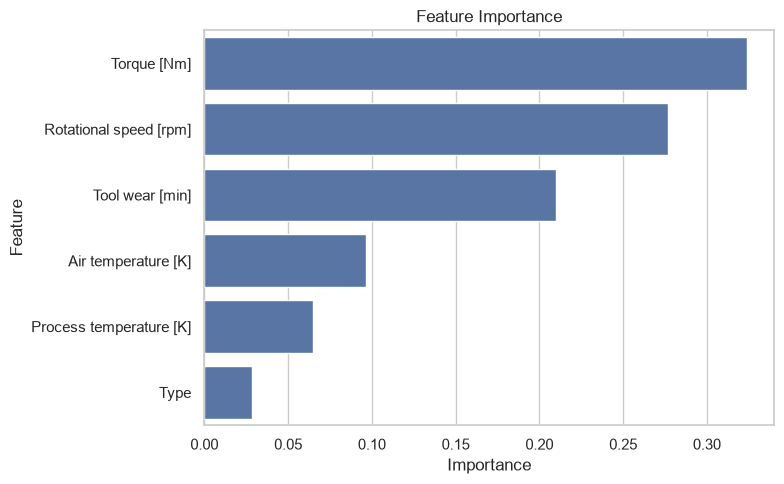

In [73]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=importance,

    x='Importance',

    y='Feature'

)

plt.title("Feature Importance")

plt.tight_layout()

plt.savefig("../images/feature_importance.png",
            dpi=300)

plt.show()

In [74]:
# Save the Final Model
import joblib

joblib.dump(

    best_rf,

    "../models/final_model.pkl"

)

print("Final model saved successfully.")

Final model saved successfully.


In [75]:
# Save Feature Importance
importance.to_csv(

    "../reports/feature_importance.csv",

    index=False

)

In [76]:
# Save Predictions
predictions = pd.DataFrame({

    'Actual': y_test,

    'Predicted': y_pred

})

predictions.to_csv(

    "../reports/predictions.csv",

    index=False

)

### Deploying on Streamlit cloud

In [4]:
import joblib

model = joblib.load("../models/final_model.pkl")

print(model)

RandomForestClassifier(n_estimators=200, random_state=42)


In [5]:
print(model.feature_names_in_)

['Type' 'Air temperature [K]' 'Process temperature [K]'
 'Rotational speed [rpm]' 'Torque [Nm]' 'Tool wear [min]']


In [11]:
import pandas as pd

df = pd.read_csv("../data/predictive_maintenance.csv")

In [12]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

# Drop unnecessary columns
df_ml.drop(["UDI", "Product ID"], axis=1, inplace=True)

# Encode Machine Type
le = LabelEncoder()
df_ml["Type"] = le.fit_transform(df_ml["Type"])

# Features
X = df_ml.drop("Target", axis=1)

# Target
y = df_ml["Target"]

print(X.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
      dtype='str')


In [13]:
import joblib

best_rf = joblib.load("../models/final_model.pkl")

In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Torque [Nm],0.323841
3,Rotational speed [rpm],0.276831
5,Tool wear [min],0.209980
1,Air temperature [K],0.096544
2,Process temperature [K],0.064609
0,Type,0.028194


In [15]:
importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

In [16]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("../data/predictive_maintenance.csv")

In [18]:
# Make a copy
df_ml = df.copy()

# Remove unnecessary columns
df_ml.drop(["UDI", "Product ID"], axis=1, inplace=True)

# Encode Machine Type
encoder = LabelEncoder()

df_ml["Type"] = encoder.fit_transform(df_ml["Type"])

# Features and Target
X = df_ml.drop("Target", axis=1)

y = df_ml["Target"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
scaler = joblib.load("../models/scaler.pkl")

In [21]:
X_train_scaled = scaler.transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [22]:
model = joblib.load("../models/final_model.pkl")

/Users/leenagaikwad/Library/CloudStorage/GoogleDrive-leena.g@iiphh.org/My Drive/DS AI-ML IITG/Assignments/Predictive_Maintenance_Project/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


<Figure size 600x500 with 0 Axes>

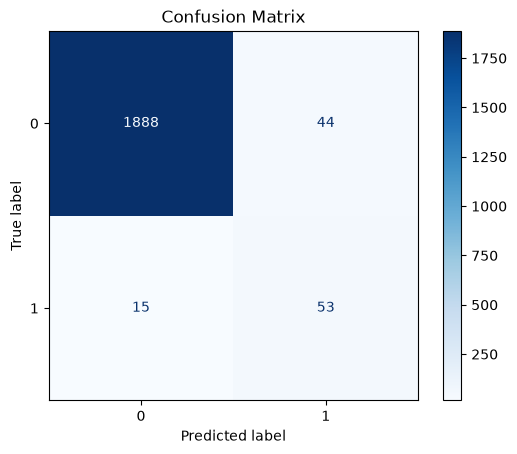

In [23]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/Users/leenagaikwad/Library/CloudStorage/GoogleDrive-leena.g@iiphh.org/My Drive/DS AI-ML IITG/Assignments/Predictive_Maintenance_Project/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


<Figure size 600x500 with 0 Axes>

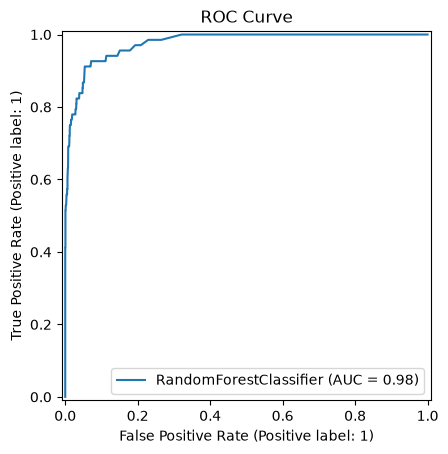

In [24]:
plt.figure(figsize=(6,5))

RocCurveDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")

plt.savefig(
    "../images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
feature_names = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

importance

,Feature,Importance
4,Torque [Nm],0.323841
3,Rotational speed [rpm],0.276831
5,Tool wear [min],0.209980
1,Air temperature [K],0.096544
2,Process temperature [K],0.064609
0,Type,0.028194
